# Budget Risk Parity

This notebook demonstrates custom risk budgets vs. equal risk contribution (ERC).
The `risk_budgets` parameter on `relaxed_risk_parity_portfolio` allows specifying
per-asset risk contribution targets that sum to 1.

In [1]:
import numpy as np
import pandas as pd
from pyvallocation import PortfolioWrapper

assets = ["Tech", "Health", "Value", "Bonds"]
mu = pd.Series([0.08, 0.06, 0.05, 0.03], index=assets)
cov = pd.DataFrame(
    [[0.090, 0.040, 0.025, 0.010],
     [0.040, 0.070, 0.020, 0.015],
     [0.025, 0.020, 0.060, 0.018],
     [0.010, 0.015, 0.018, 0.045]],
    index=assets, columns=assets,
)
wrapper = PortfolioWrapper.from_moments(mu, cov)

In [2]:
# Equal Risk Contribution (default)
w_erc, _, _, diag_erc = wrapper.relaxed_risk_parity_portfolio_with_diagnostics(
    lambda_reg=0.0, target_multiplier=None
)
print("ERC weights:")
print(w_erc.round(4))
print("\nRisk contributions (%):", diag_erc["risk_contributions_pct"].round(1))

ERC weights:
Tech      0.2065
Health    0.2261
Value     0.2513
Bonds     0.3162
Name: Relaxed Risk Parity, dtype: float64

Risk contributions (%): [25. 25. 25. 25.]


In [3]:
# Custom budgets: 50% risk from Tech, 20% Health, 20% Value, 10% Bonds
budgets = np.array([0.50, 0.20, 0.20, 0.10])
w_rb, _, _, diag_rb = wrapper.relaxed_risk_parity_portfolio_with_diagnostics(
    lambda_reg=0.0, target_multiplier=None, risk_budgets=budgets
)
print("Budget RP weights:")
print(w_rb.round(4))
print("\nRisk contributions (%):", diag_rb["risk_contributions_pct"].round(1))

Budget RP weights:
Tech      0.3725
Health    0.2013
Value     0.2376
Bonds     0.1887
Name: Relaxed Risk Parity, dtype: float64

Risk contributions (%): [50. 20. 20. 10.]


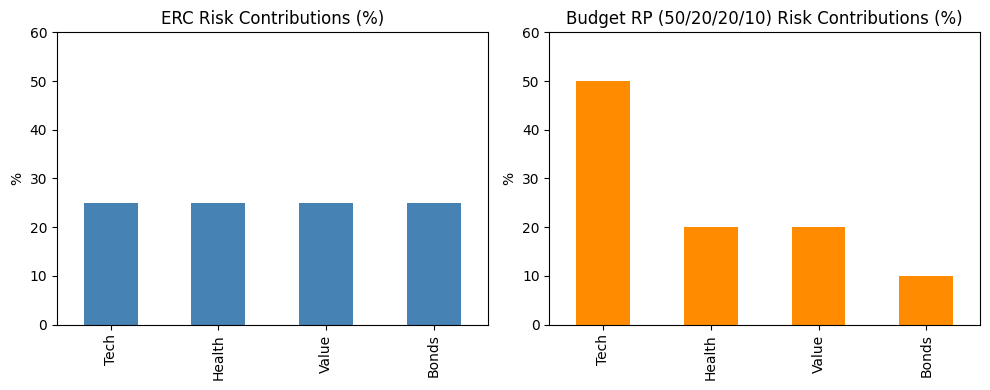

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pd.Series(diag_erc["risk_contributions_pct"], index=assets).plot.bar(
    ax=axes[0], color="steelblue", title="ERC Risk Contributions (%)"
)
pd.Series(diag_rb["risk_contributions_pct"], index=assets).plot.bar(
    ax=axes[1], color="darkorange", title="Budget RP (50/20/20/10) Risk Contributions (%)"
)
for ax in axes:
    ax.set_ylabel("%")
    ax.set_ylim(0, 60)
fig.tight_layout()
plt.show()